# Testing Notebook

# Ignore Trainig and Validation Accuracy, those are not objective truth measruements they are more just a guage to see how far the model is from the actual postion of the car
# Also ignore those metrics for the funciton reportFinalMetrics

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import config as cfg
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from Data.data_loading import load_and_preprocess_data, create_tensor_from_dataframe, create_sequences, create_dataloaders 
from Training.train_matt import Trainer
from Training.basicEval import plotLoss, plotAccuracy, reportFinalMetrics, reportMultiFinalMetrics, plotMultiAccuracy, plotMultiLoss
from Model.model_split import FrameTransformer, print_model_info

from Training.customLoss import ADELoss, FDELoss, RMSELoss

Using GPU


W0505 12:13:13.154000 28624 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
root_dir = os.getcwd()  # Use current working directory as root
data_dir = os.path.join(root_dir, 'Data')
csv_dir = os.path.join(data_dir, 'csv')
csv_file = os.path.join(csv_dir, 'trimmed_IMG_4097_detections.csv')

print("Data directory: ", data_dir)
print("CSV directory: ", csv_dir)
print("CSV file: ", csv_file)


model_dir = os.path.join(root_dir, 'Model')
save_model_dir = os.path.join(model_dir, 'Saved_Model')
print("Model directory: ", model_dir)
print("Saved model directory: ", save_model_dir)


Data directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data
CSV directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv
CSV file:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv\trimmed_IMG_4097_detections.csv
Model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model
Saved model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model


In [3]:
ADE = ADELoss()
FDE = FDELoss()
RMSE = RMSELoss()

In [4]:
df, transformer_max_ids_per_frame, frame_scaler = load_and_preprocess_data(csv_folder=csv_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)


All CSVs now have 599 frames after trimming
Minimum records per ID: 3
Average records per ID: 1763.55
Maximum records per ID: 3209

Minimum IDs (Vehicles) per frame: 5
Average IDs (Vehicles) per frame: 14.34
Maximum IDs (Vehicles) per frame: 20

After normalization:
X range: 0.0000 to 5.0000
Y range: 0.0000 to 5.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000
All data tensor shape: torch.Size([6, 599, 20, 5])


# MSE

In [5]:
# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


In [6]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses1, val_losses1, train_accs1, val_accs1, epoch_times1 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=nn.MSELoss(), 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 258.55 seconds, or 4.31 minutes
Total epochs run: 50
Average time per epoch: 5.17 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.4561
Final Validation Loss: 0.4836
Final Training Accuracy: 92.87%
Final Validation Accuracy: 92.82%


In [7]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'mse_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

Saving model to:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model\mse_model.pth


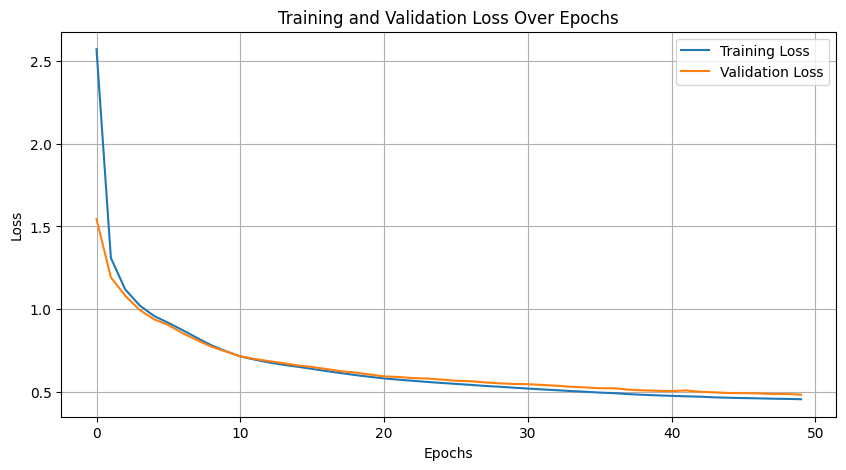

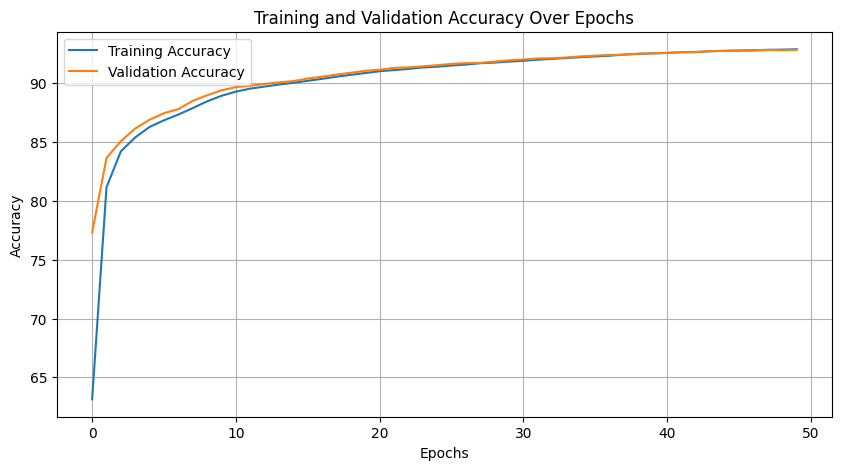

Final Training Accuracy: 0.46%
Final Validation Accuracy: 0.48%
Final Training Loss: 92.8727
Final Validation Loss: 92.8193
Total Training Time: 258.52 seconds


In [8]:
plotLoss(train_losses1, val_losses1)
plotAccuracy(train_accs1, val_accs1)
reportFinalMetrics(train_losses1, val_losses1, train_accs1, val_accs1, epoch_times1)

# ADE

In [9]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses2, val_losses2, train_accs2, val_accs2, epoch_times2 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=ADE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 250.62 seconds, or 4.18 minutes
Total epochs run: 50
Average time per epoch: 5.01 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.4081
Final Validation Loss: 0.4726
Final Training Accuracy: 93.44%
Final Validation Accuracy: 93.28%


In [10]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'ADE_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

Saving model to:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model\ADE_model.pth


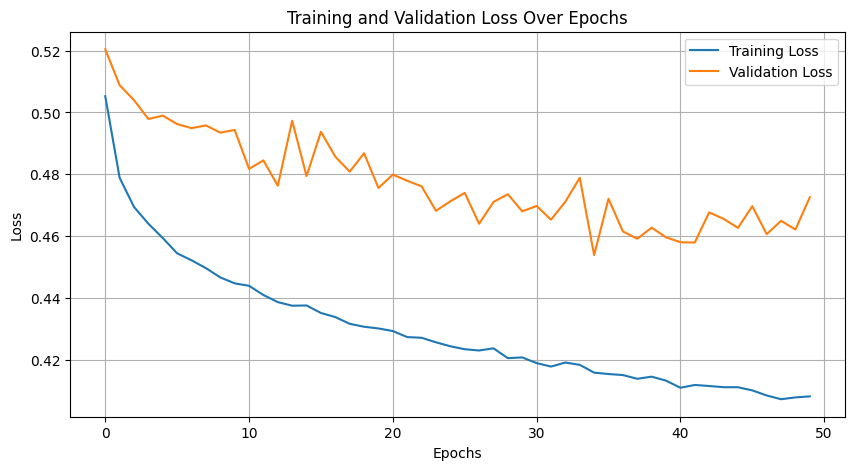

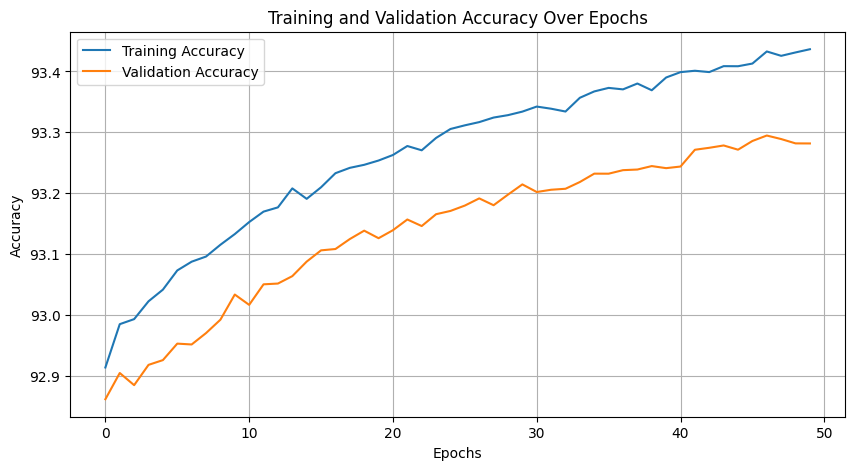

Final Training Accuracy: 0.41%
Final Validation Accuracy: 0.47%
Final Training Loss: 93.4365
Final Validation Loss: 93.2818
Total Training Time: 250.59 seconds


In [11]:
plotLoss(train_losses2, val_losses2)
plotAccuracy(train_accs2, val_accs2)
reportFinalMetrics(train_losses2, val_losses2, train_accs2, val_accs2, epoch_times2)

# FDE

In [12]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses3, val_losses3, train_accs3, val_accs3, epoch_times3 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=FDE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 251.64 seconds, or 4.19 minutes
Total epochs run: 50
Average time per epoch: 5.03 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.2818
Final Validation Loss: 0.4963
Final Training Accuracy: 90.47%
Final Validation Accuracy: 90.28%


In [13]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'FDE_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

Saving model to:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model\FDE_model.pth


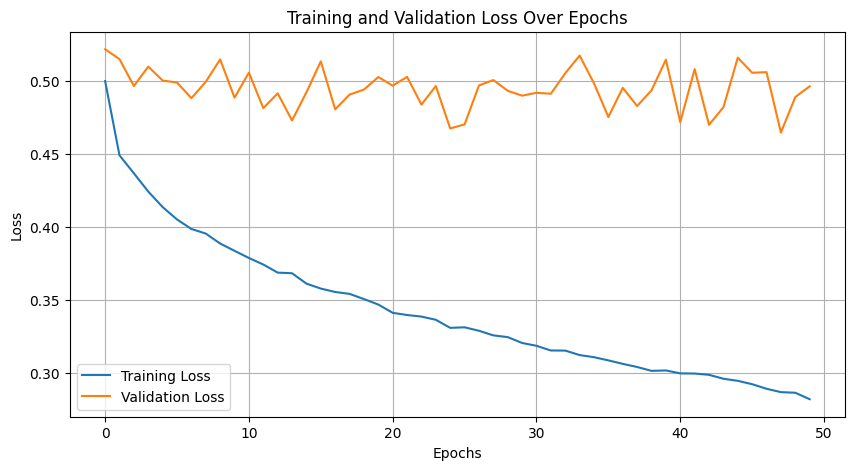

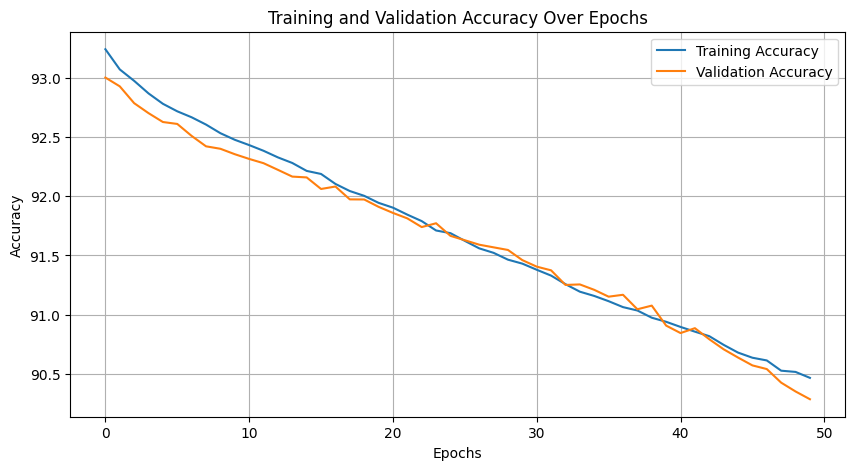

Final Training Accuracy: 0.28%
Final Validation Accuracy: 0.50%
Final Training Loss: 90.4652
Final Validation Loss: 90.2846
Total Training Time: 251.61 seconds


In [14]:
plotLoss(train_losses3, val_losses3)
plotAccuracy(train_accs3, val_accs3)
reportFinalMetrics(train_losses3, val_losses3, train_accs3, val_accs3, epoch_times3)

# RSME

In [15]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 252.08 seconds, or 4.20 minutes
Total epochs run: 50
Average time per epoch: 5.04 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.5976
Final Validation Loss: 0.6479
Final Training Accuracy: 92.92%
Final Validation Accuracy: 92.92%


In [16]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'RSME_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

Saving model to:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model\RSME_model.pth


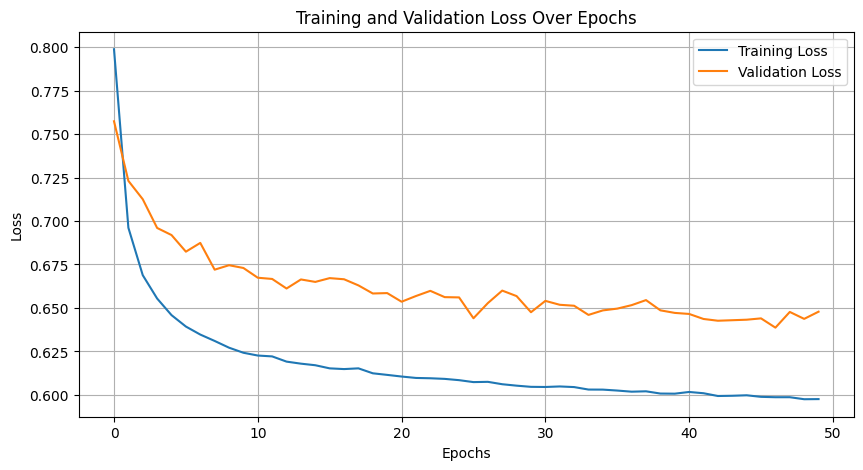

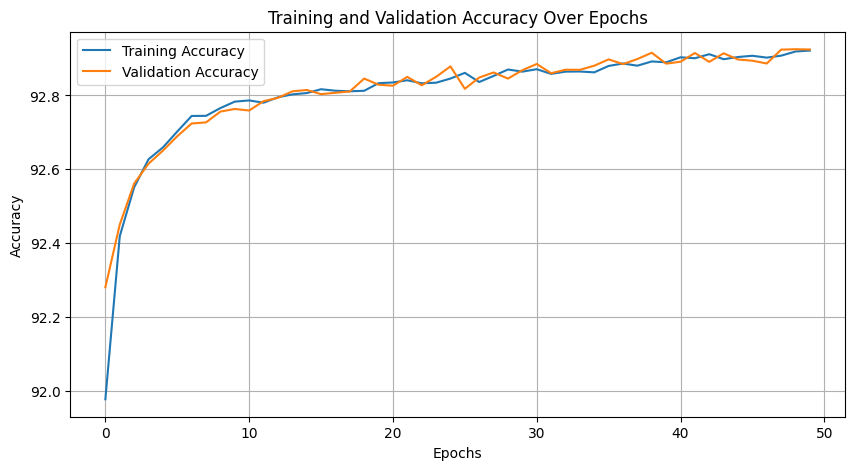

Final Training Accuracy: 0.60%
Final Validation Accuracy: 0.65%
Final Training Loss: 92.9217
Final Validation Loss: 92.9245
Total Training Time: 252.05 seconds


In [17]:
plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)

# Combined Plots

In [18]:
multi_train_losses = [train_losses1, train_losses2, train_losses3, train_losses4]
multi_val_losses = [val_losses1, val_losses2, val_losses3, val_losses4]
multi_train_accs = [train_accs1, train_accs2, train_accs3, train_accs4]
multi_val_accs = [val_accs1, val_accs2, val_accs3, val_accs4]
multi_epoch_times = [epoch_times1, epoch_times2, epoch_times3, epoch_times4]

model_names = ['MSE', 'ADE', 'FDE', 'RMSE']

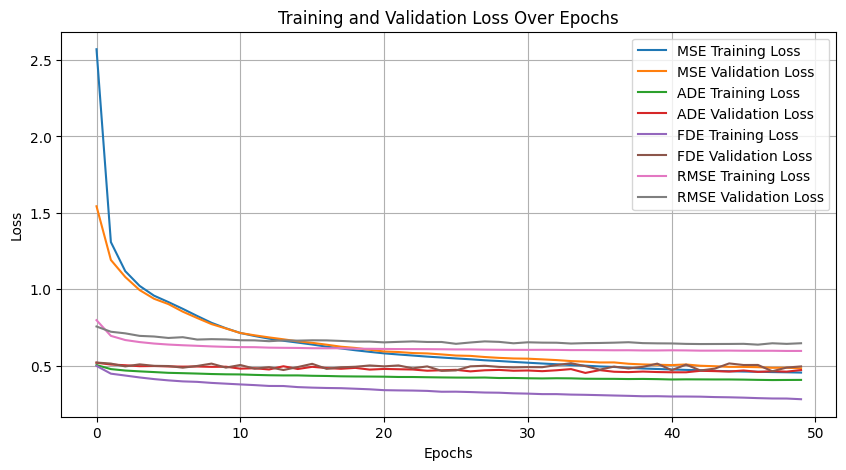

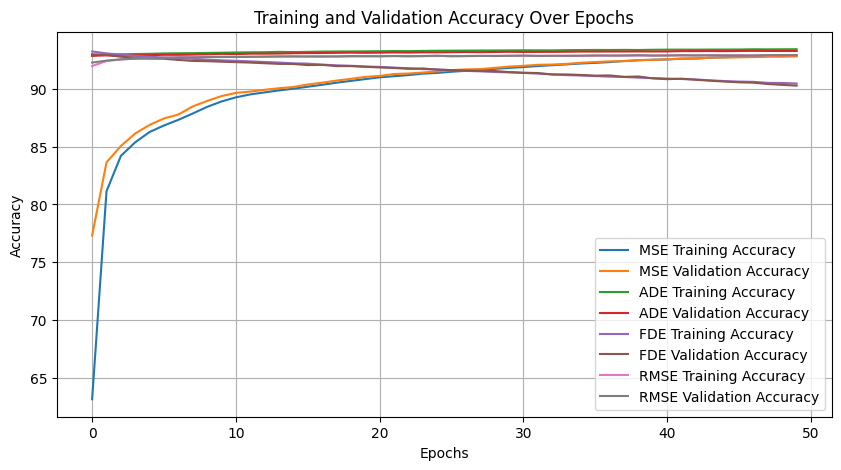

In [21]:
plotMultiLoss(model_names, multi_train_losses, multi_val_losses)
plotMultiAccuracy(model_names, multi_train_accs, multi_val_accs)